In [1]:
from datetime import date
import time

import warnings
warnings.filterwarnings(action='once')


from fidelity import *
from povm import *
%matplotlib inline


today = date.today()
datestr = today.strftime("%y%m%d")


# Hyperparameters
Nq = 6
split = 0.8

povm = POVM('pauli6')
Na = povm.Na

In [2]:
# GHZ state density matrix
Ne = 4
rhoKB = np.zeros((Ne, 2*Nq), dtype=int)
rhoAmp = np.zeros((Ne), dtype=complex)

rhoKB[1, :] = 1
rhoKB[2, :Nq] = 1
rhoKB[3, Nq:] = 1

rhoAmp[0] = 0.5
rhoAmp[1] = 0.5
rhoAmp[2] = 0.5
rhoAmp[3] = np.conj(rhoAmp[2])


density = {}
density['KB'] = rhoKB
density['Amp'] = rhoAmp


ghz = SampleDM(Nq, povm, density)


In [3]:
# Initialize data

Ns = 40000

Nv = 4000

data_fname = 'data/ghz-sim-Pauli6-Nq%i-Ns%i.npy'%(Nq, Ns)

data = GenerateData(ghz, Ns, data_fname)


traindata = data[:int(len(data)*split)]
testdata = data[int(len(data)*split):]

valdata = ghz.samples(Ns=Nv)

Loading data: data/ghz-sim-Pauli6-Nq6-Ns40000.npy


# AQT reconstruction

In [4]:
from ann import *


print(torch.cuda.is_available())
device = torch.device("cuda:0")

Neplist = np.array([600])
Nlayer, dmodel, Nh = 2, 64, 4

tag = 'aqt-ghz-large'

True


In [5]:
cflist = np.zeros(Neplist.shape)

t0 = time.time()

for epi in range(len(Neplist)):
    Nep = Neplist[epi]
    
    model = InitializeModel(Nq, Nlayer=Nlayer, dmodel=dmodel, Nh=Nh, Na=Na, dropout=0.0).to(device)

    t = time.time()
    model, losses = TrainModel(model, traindata, testdata, device, smoothing=0.0, batch_size=100,lr=1e-4,Nep=Nep)
    print('Took %f minutes'%((time.time()-t)/60))

    model.to('cpu')

    torch.save(model, 'mod/%s-%i_%i-%i-%i_%i-%i.mod'%(tag, Nep, Nlayer, dmodel, Nh, Nq, Ns))

    cflist[epi] = ClFidEst(ghz, model, samples=valdata)

/home/peter/Box/CMT/projects/ml/python/ann.py:443: UserWarning: nn.init.xavier_uniform is now deprecated in favor of nn.init.xavier_uniform_.
  nn.init.xavier_uniform(p)
/home/peter/.local/lib/python3.6/site-packages/torch/nn/_reduction.py:43: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))


1 : 1.454137569665909
2 : 1.4376606613397598
3 : 1.4335329785943032
4 : 1.432157725095749
5 : 1.4312975376844406
6 : 1.4309279188513755
7 : 1.4307607218623162
8 : 1.4304479196667672
9 : 1.4302355840802192
10 : 1.4300340726971625
11 : 1.42993855625391
12 : 1.4299224406480788
13 : 1.429841536283493
14 : 1.429731974005699
15 : 1.429740957915783
16 : 1.4296209380030631
17 : 1.4296673521399499
18 : 1.4294552490115167
19 : 1.429487130045891
20 : 1.429349172115326
21 : 1.4292407840490342
22 : 1.4292954236268998
23 : 1.4292474299669267
24 : 1.4291144415736199
25 : 1.4289532974362373
26 : 1.4291068226099015
27 : 1.4290616020560265
28 : 1.429148617386818
29 : 1.4290606021881103
30 : 1.428975595533848
31 : 1.4290003269910811
32 : 1.4288613721728325
33 : 1.4288231775164604
34 : 1.4288932263851166
35 : 1.4288877502083779
36 : 1.428797833621502
37 : 1.4287392616271972
38 : 1.4287734910845757
39 : 1.4287278801202774
40 : 1.4287178352475167
41 : 1.4286452785134316
42 : 1.4285489618778229
43 : 1.428737

337 : 1.4218432292342187
338 : 1.4216636806726455
339 : 1.421549418568611
340 : 1.4214517936110496
341 : 1.4214352265000343
342 : 1.4215934813022613
343 : 1.4214343816041946
344 : 1.4214288964867592
345 : 1.421493561565876
346 : 1.4214149087667465
347 : 1.4214056476950645
348 : 1.4213411822915076
349 : 1.4213639944791794
350 : 1.4213422581553459
351 : 1.4212684482336044
352 : 1.4211401343345642
353 : 1.421180498600006
354 : 1.4212442964315415
355 : 1.4211999863386153
356 : 1.4210922107100488
357 : 1.4211156487464904
358 : 1.4211803823709488
359 : 1.421155323088169
360 : 1.4210215389728547
361 : 1.421079085767269
362 : 1.4209990933537484
363 : 1.4209278225898743
364 : 1.4210059344768524
365 : 1.420956052839756
366 : 1.4208575993776322
367 : 1.4209720715880394
368 : 1.4208521515130996
369 : 1.4209230229258538
370 : 1.4209345504641533
371 : 1.4208537876605987
372 : 1.4209691107273101
373 : 1.420909935235977
374 : 1.4209190383553505
375 : 1.420841284096241
376 : 1.4207789689302444
377 : 1.

(0.9890029489983228, 1)

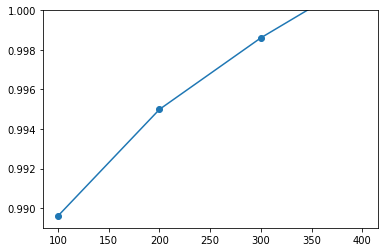

In [30]:
plt.plot(Neplist, cflist, marker='.', markersize=12)
plt.ylim(top=1)

In [31]:
st1 = 0
st2 = 2**Nq-1

for epi in range(len(Neplist)):
    Nep = Neplist[epi]
    model = torch.load(f='mod/%s-%i_%i-%i-%i_%i-%i.mod'%(tag, Nep, Nlayer, dmodel, Nh, Nq, Ns))
    
    ptab_model = POVMProbTable(model)
    print(GetDMElement(st1, st2, ptab_model, Nq, POVM('pauli6')))
    

(0.0014734897506774002-0.0009649817706454232j)
(0.38994257157880896-0.022940074026180216j)
(0.4928963403983761-0.019196953477846567j)
(0.5017350358065614-0.018190802026055844j)


In [33]:
Nep = 400

model = torch.load(f='mod/%s-%i_%i-%i-%i_%i-%i.mod'%(tag, Nep, Nlayer, dmodel, Nh, Nq, Ns))

ptab_model = POVMProbTable(model)

dm_model = GetDMFull(ptab_model, Nq, POVM('pauli6'))

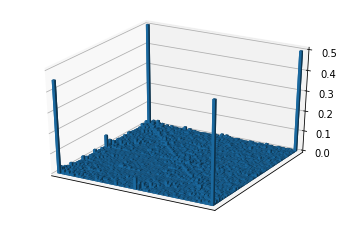

/home/peter/.local/lib/python3.6/site-packages/ipykernel_launcher.py:9: MatplotlibDeprecationWarning: 
The frameon kwarg was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use facecolor instead.
  if __name__ == '__main__':


In [36]:
# dm_model = np.load('data/%s-Nq%i-Ns%i-dm.npy'%(datestr, Nq, Ns))

fig_model = plotDM(dm_model, Nq)
plt.show(fig_model)

np.save('dm/final-Nq%i-Ns%i.npy'%(Nq, Ns), dm_model)


# fig_model.savefig('figures/fig4.pdf', dpi=300, frameon=True,bbox_inches="tight")